In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


In [15]:
img1 = cv2.imread('eiffel1.png')
img2 = cv2.imread('eiffel2.png')

img2 = cv2.resize(img2, (img1.shape[1], img1.shape[0]))

gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

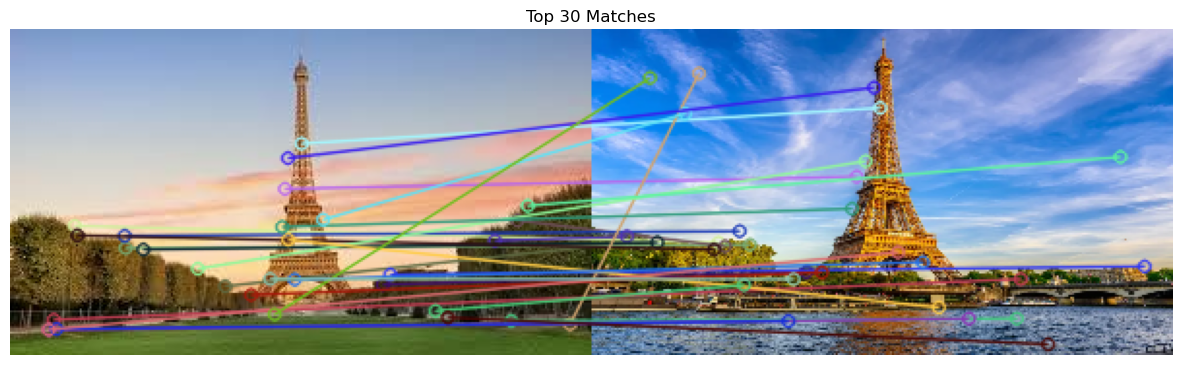

In [21]:
sift = cv2.SIFT_create()

kp1, des1 = sift.detectAndCompute(gray1, None)
kp2, des2 = sift.detectAndCompute(gray2, None)

bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=True)
matches = bf.match(des1, des2)
matches = sorted(matches, key=lambda x: x.distance)

matched_img = cv2.drawMatches(
    img1, kp1, img2, kp2, matches[:30], None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

plt.figure(figsize=(15, 10))
plt.imshow(cv2.cvtColor(matched_img, cv2.COLOR_BGR2RGB))
plt.title('Top 30 Matches')
plt.axis('off')
plt.show()

The SIFT finds multiple points of the sky and try to relate the eiffel tower to other components, we could try segmentation before runing SIFT